In [1]:
# --- preparação do ambiente (rode esta célula primeiro) ---
# Acha a raiz do projeto; se não existir, estamos no Colab e o repositório é clonado.
import os
import pathlib
import subprocess

REPOSITORIO = "https://github.com/thxggz/dr1-at-algoritmos.git"
DESTINO_CLONE = pathlib.Path("/content/dr1-at-algoritmos")


def raiz_do_projeto() -> pathlib.Path | None:
    """Primeiro diretório, subindo a partir do atual, que contenha src/counters.py."""
    for base in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]:
        if (base / "src" / "counters.py").exists():
            return base
    return None


raiz = raiz_do_projeto()
if raiz is None:
    if not DESTINO_CLONE.exists():
        subprocess.run(
            ["git", "clone", "--depth", "1", REPOSITORIO, str(DESTINO_CLONE)],
            check=True,
        )
    raiz = DESTINO_CLONE
os.chdir(raiz)
print(f"raiz do projeto: {raiz}")
print("o código vive em src/; este notebook importa e demonstra")

raiz do projeto: C:\Users\kikea\dr1-at-aed
o código vive em src/; este notebook importa e demonstra


# Exercício 3 — Otimização orientada a Big O

**Henrique Goldstein Maluhy Mendes Amaral** · Infnet · DR1_AT — Algoritmos e Estruturas de Dados

Este notebook cobre **um** exercício. O código está em `src/`, testado por `pytest`; aqui ele é importado e demonstrado. A primeira célula prepara o ambiente — rode-a antes das outras, ou use **Ambiente de execução → Executar tudo**.

**Os doze exercícios:**

1. [Exercício 1](https://colab.research.google.com/github/thxggz/dr1-at-algoritmos/blob/main/colab/ex01_buscas.ipynb)
2. [Exercício 2](https://colab.research.google.com/github/thxggz/dr1-at-algoritmos/blob/main/colab/ex02_ordenacoes_quadraticas.ipynb)
3. Exercício 3 **→ você está aqui**
4. [Exercício 4](https://colab.research.google.com/github/thxggz/dr1-at-algoritmos/blob/main/colab/ex04_hashtable.ipynb)
5. [Exercício 5](https://colab.research.google.com/github/thxggz/dr1-at-algoritmos/blob/main/colab/ex05_pilha_fila_expressao.ipynb)
6. [Exercício 6](https://colab.research.google.com/github/thxggz/dr1-at-algoritmos/blob/main/colab/ex06_simulador_de_filas.ipynb)
7. [Exercício 7](https://colab.research.google.com/github/thxggz/dr1-at-algoritmos/blob/main/colab/ex07_recursao_diretorios.ipynb)
8. [Exercício 8](https://colab.research.google.com/github/thxggz/dr1-at-algoritmos/blob/main/colab/ex08_programacao_dinamica.ipynb)
9. [Exercício 9](https://colab.research.google.com/github/thxggz/dr1-at-algoritmos/blob/main/colab/ex09_quicksort_quickselect.ipynb)
10. [Exercício 10](https://colab.research.google.com/github/thxggz/dr1-at-algoritmos/blob/main/colab/ex10_lista_encadeada.ipynb)
11. [Exercício 11](https://colab.research.google.com/github/thxggz/dr1-at-algoritmos/blob/main/colab/ex11_lista_dupla_deque.ipynb)
12. [Exercício 12](https://colab.research.google.com/github/thxggz/dr1-at-algoritmos/blob/main/colab/ex12_motor_de_indexacao.ipynb)

---


---
# Seção 0 — Instrumentação compartilhada

Antes dos exercícios, a peça de que todos dependem.

Existe **um único** contador, definido em `src/counters.py` e reutilizado pelos
12 exercícios. Sem isso, "o insertion sort faz 4.193 comparações" e "a BST faz
1.904.423" não seriam números comparáveis.

```python
@dataclass
class Counters:
    comparisons: int = 0   # comparações de chaves
    copies: int = 0        # movimentações (1 troca = 3 cópias)
    calls: int = 0         # chamadas recursivas
    hops: int = 0          # saltos de ponteiro em estrutura encadeada
```

**Os três primeiros são exigência do enunciado.** O quarto, `hops`, foi
acrescentado — e a razão é o exercício 10: com ponteiro `tail`, `insert_last`
faz 0 comparações e 1 cópia, *exatamente como* a versão sem `tail`. Os
contadores obrigatórios são cegos para a diferença entre O(1) e O(n) ali. Sem
`hops`, a evidência quantitativa que a rubrica cobra não existiria.

**Critérios fixos, válidos no trabalho inteiro:**

- uma **troca** conta 3 cópias (`tmp = a; a = b; b = tmp`); um **deslocamento**
  conta 1;
- uma **sondagem** de busca (linear, binária ou descida em BST) conta **uma**
  comparação de três vias, não duas;
- toda função instrumentada aceita um `Counters` do chamador e tem um irmão
  `*_counted` que devolve `(resultado, Counters)`.

In [2]:
from __future__ import annotations

import math
import pathlib
import subprocess
import sys
import warnings

import matplotlib.pyplot as plt
import pandas as pd

RAIZ = pathlib.Path.cwd().parent if pathlib.Path.cwd().name == "notebook" else pathlib.Path.cwd()
if str(RAIZ) not in sys.path:
    sys.path.insert(0, str(RAIZ))
FIGURAS = RAIZ / "figures"
FIGURAS.mkdir(exist_ok=True)

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
plt.rcParams.update({"figure.figsize": (9, 4.5), "figure.dpi": 110, "axes.grid": True,
                     "grid.alpha": 0.3, "font.size": 9})
warnings.filterwarnings("ignore", category=FutureWarning)

from src.counters import COPIES_PER_SWAP, RANDOM_SEED, Counters

print(f"semente dos experimentos: {RANDOM_SEED}")
print(f"uma troca conta {COPIES_PER_SWAP} cópias")
print(f"campos do contador: {list(Counters().as_dict())}")

semente dos experimentos: 42
uma troca conta 3 cópias
campos do contador: ['comparisons', 'copies', 'calls', 'hops']


In [3]:
def mostrar(df: pd.DataFrame, colunas: list[str] | None = None, titulo: str = "") -> pd.DataFrame:
    """Exibe a tabela de medições, opcionalmente só com as colunas pedidas."""
    if titulo:
        print(titulo)
    return df[colunas] if colunas else df


def grafico_loglog(df, x, y, grupo, titulo, arquivo, ylabel=None):
    """Gráfico log-log — usado sempre que há 4 ou mais pontos por curva."""
    fig, ax = plt.subplots()
    for nome, parte in df.groupby(grupo, sort=False):
        parte = parte.sort_values(x)
        ax.plot(parte[x], parte[y], marker="o", label=str(nome))
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel(x); ax.set_ylabel(ylabel or y)
    ax.set_title(titulo); ax.legend(fontsize=8)
    fig.tight_layout()
    fig.savefig(FIGURAS / arquivo, bbox_inches="tight")
    plt.show()


def grafico_razao(df, x, y, grupo, titulo, arquivo, ylabel=None):
    """Razão contra a curva teórica: reta horizontal = a classe está certa."""
    fig, ax = plt.subplots()
    for nome, parte in df.groupby(grupo, sort=False):
        parte = parte.sort_values(x)
        ax.plot(parte[x], parte[y], marker="o", label=str(nome))
    ax.set_xscale("log")
    ax.set_xlabel(x); ax.set_ylabel(ylabel or y)
    ax.set_title(titulo); ax.legend(fontsize=8)
    fig.tight_layout()
    fig.savefig(FIGURAS / arquivo, bbox_inches="tight")
    plt.show()


def veredito(texto: str) -> None:
    """Conclusão calculada a partir da tabela imediatamente acima."""
    print("\n" + "=" * 78)
    print(texto)
    print("=" * 78)

In [4]:
# Estruturas definidas na seção de outro exercício do notebook
# único, reimportadas aqui para este notebook rodar sozinho.
from src.bst import BinarySearchTree
from src.searching import generate_array

---
# Exercício 3 — Otimização orientada a Big O

## Enunciado
Reescrever `deduplicate_slow` O(n²) como `deduplicate_fast` O(n) preservando a
ordem do primeiro aparecimento, implementar `k_smallest` em duas versões
(ordenar tudo × quickselect) e uma terceira em BST por travessia controlada, e
**demonstrar com medição** a degeneração da BST.

## Implementação — `src/selection.py`

**Decisão de projeto 1 — a deduplicação rápida usa a `HashTableChained` do
exercício 4, não um `set`.** Além de a convenção proibir estrutura pronta, há
ganho colateral: as comparações dentro dos buckets são **contadas**, então o
"O(n)" da versão rápida é medido no mesmo contador que o "O(n²)" da lenta. Com
`set`, a comparação viraria O(n²) contra "zero", o que não é honesto.

In [5]:
from src.selection import (bench_deduplicate, bench_k_smallest, bench_k_smallest_bst,
                           deduplicate_fast, deduplicate_slow, k_smallest_bst,
                           k_smallest_quickselect, k_smallest_sort)
import random as _rnd

# equivalência das duas deduplicações, contra modelo de referência
rng = _rnd.Random(RANDOM_SEED)
for _ in range(200):
    amostra = [rng.randrange(12) for _ in range(rng.randrange(0, 50))]
    referencia = list(dict.fromkeys(amostra))   # ordem do 1º aparecimento
    assert deduplicate_slow(amostra) == referencia
    assert deduplicate_fast(amostra) == referencia
print("as duas deduplicações produzem a MESMA saída em 200 entradas sorteadas")
print(f"exemplo: {[3,1,3,2,1,4]} → {deduplicate_fast([3,1,3,2,1,4])}")

# equivalência das três versões de k menores
dados = generate_array(300, "aleatorio")
arvore_k = BinarySearchTree(dados)
for k in (0, 1, 10, 150, 300):
    esperado = sorted(dados)[:k]
    assert k_smallest_sort(dados, k) == esperado
    assert k_smallest_quickselect(dados, k) == esperado
    assert k_smallest_bst(arvore_k.root, k) == esperado
print("as três versões de k_smallest concordam para k em {0, 1, 10, 150, 300}")

as duas deduplicações produzem a MESMA saída em 200 entradas sorteadas
exemplo: [3, 1, 3, 2, 1, 4] → [3, 1, 2, 4]
as três versões de k_smallest concordam para k em {0, 1, 10, 150, 300}


In [6]:
dedup = pd.DataFrame(bench_deduplicate())
mostrar(dedup[dedup["n"] == 4_000],
        ["padrao", "u_distintos", "lenta_comparacoes", "lenta/n2", "lenta/(n*u)",
         "rapida_comparacoes", "rapida/n", "razao_lenta_sobre_rapida", "razao_tempo",
         "memoria_extra_lenta", "memoria_extra_rapida"],
        "DEDUPLICAÇÃO: lenta × rápida (n = 4.000)")

DEDUPLICAÇÃO: lenta × rápida (n = 4.000)


,padrao,u_distintos,lenta_comparacoes,lenta/n2,lenta/(n*u),rapida_comparacoes,rapida/n,razao_lenta_sobre_rapida,razao_tempo,memoria_extra_lenta,memoria_extra_rapida
9,5% de valores distintos,200,401800,0.0251,0.5022,4852,1.2130,82.8112,5.3227,Θ(1),Θ(u) — tabela com 200 chaves
10,50% de valores distintos,2000,4000000,0.2500,0.5000,3781,0.9453,"1,057.9212",27.3933,Θ(1),Θ(u) — tabela com 2000 chaves
11,100% de valores distintos,4000,7998000,0.4999,0.4999,2161,0.5403,"3,701.0643",10.1635,Θ(1),Θ(u) — tabela com 4000 chaves


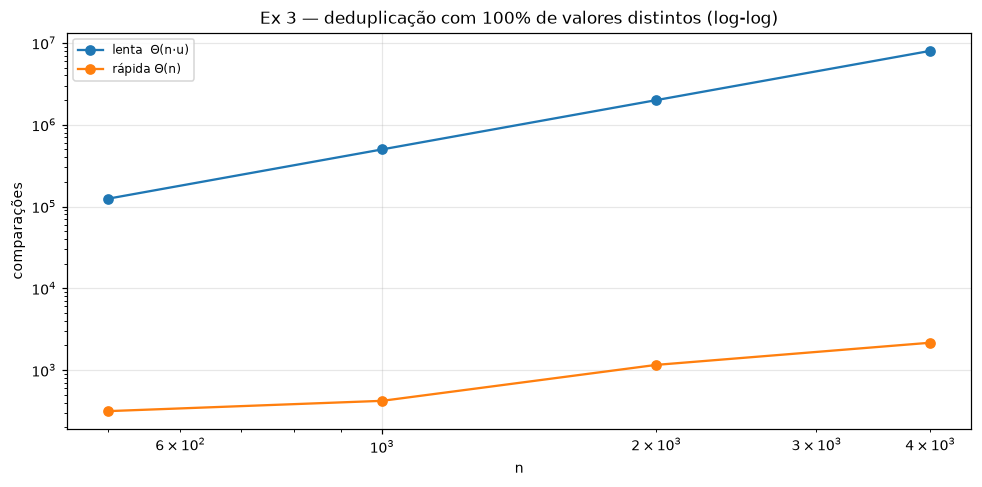


A versão lenta é Θ(n·u), não Θ(n²) cego — e a coluna prova:
    5% distintos (u=  200)  →  lenta/n² = 0.0251   mas   lenta/(n·u) = 0.5022
   50% distintos (u=2,000)  →  lenta/n² = 0.2500   mas   lenta/(n·u) = 0.5000
  100% distintos (u=4,000)  →  lenta/n² = 0.4999   mas   lenta/(n·u) = 0.4999

Com 5% de distintos a versão lenta PARECE aceitável (lenta/n² = 0,025).
Medir só o caso fácil esconderia o problema — que é o erro que o ex 3 manda corrigir.


In [7]:
comparativo = pd.concat([
    dedup[dedup["fracao_distintos"] == 1.0].assign(versao="lenta  Θ(n·u)",
                                                   comparacoes=lambda d: d["lenta_comparacoes"]),
    dedup[dedup["fracao_distintos"] == 1.0].assign(versao="rápida Θ(n)",
                                                   comparacoes=lambda d: d["rapida_comparacoes"]),
])
grafico_loglog(comparativo, "n", "comparacoes", "versao",
               "Ex 3 — deduplicação com 100% de valores distintos (log-log)",
               "ex03_deduplicacao.png", "comparações")

do_maior = dedup[dedup["n"] == 4_000].set_index("fracao_distintos")
veredito(
    "A versão lenta é Θ(n·u), não Θ(n²) cego — e a coluna prova:\n"
    + "\n".join(
        f"  {int(fr*100):>3}% distintos (u={int(linha['u_distintos']):>5,})  →  "
        f"lenta/n² = {linha['lenta/n2']:.4f}   mas   lenta/(n·u) = {linha['lenta/(n*u)']:.4f}"
        for fr, linha in do_maior.iterrows())
    + "\n\nCom 5% de distintos a versão lenta PARECE aceitável (lenta/n² = 0,025).\n"
      "Medir só o caso fácil esconderia o problema — que é o erro que o ex 3 manda corrigir."
)

In [8]:
kmenores = pd.DataFrame(bench_k_smallest(ks=(1, 10, 100, 1_000)))
mostrar(kmenores[kmenores["k"] == 10],
        ["n", "k", "A_comparacoes", "A/n", "A/n_log2n", "B_comparacoes", "B/n",
         "razao_A_sobre_B"],
        "k MENORES (k = 10): versão A (ordenar tudo) × versão B (quickselect)")

k MENORES (k = 10): versão A (ordenar tudo) × versão B (quickselect)


,n,k,A_comparacoes,A/n,A/n_log2n,B_comparacoes,B/n,razao_A_sobre_B
1,1000,10,10437,10.4370,1.0473,2400,2.4000,4.3487
5,4000,10,51194,12.7985,1.0696,6790,1.6975,7.5396
9,16000,10,242826,15.1766,1.0867,27020,1.6887,8.9869
13,64000,10,1124160,17.5650,1.1002,132654,2.0727,8.4744


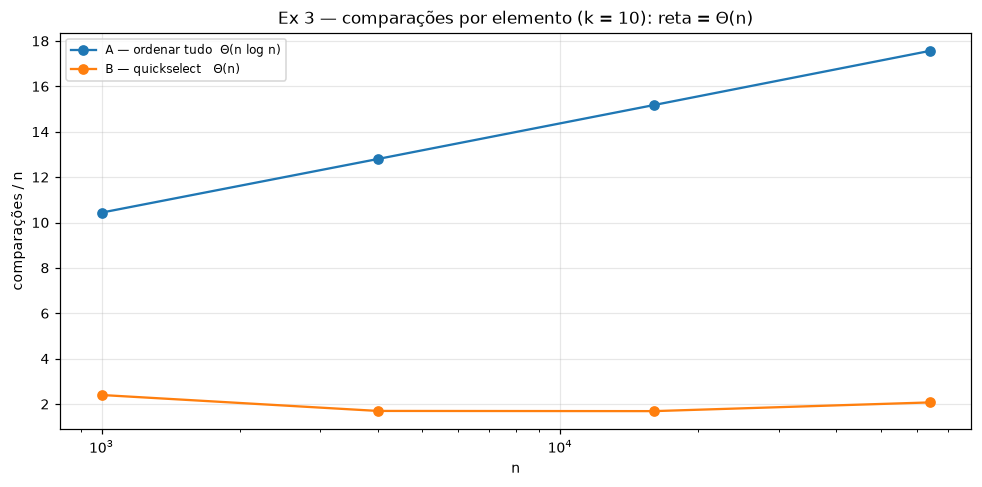


A versão A NÃO MUDA com k — ordena tudo mesmo para k=1. A insensibilidade é o defeito.
  A/n  cresce de 10.44 a 17.57 (acompanha log₂n)  ⇒ Θ(n log n)
  B/n  fica entre 1.69 e 2.40                    ⇒ Θ(n)
  ganho: 4.3× → 9.0× (cresce com n: é ganho de CLASSE, não de constante)


In [9]:
so_k10 = kmenores[kmenores["k"] == 10]
curvas = pd.concat([
    so_k10.assign(versao="A — ordenar tudo  Θ(n log n)", razao=lambda d: d["A/n"]),
    so_k10.assign(versao="B — quickselect   Θ(n)", razao=lambda d: d["B/n"]),
])
grafico_razao(curvas, "n", "razao", "versao",
              "Ex 3 — comparações por elemento (k = 10): reta = Θ(n)",
              "ex03_k_smallest.png", "comparações / n")

veredito(
    f"A versão A NÃO MUDA com k — ordena tudo mesmo para k=1. A insensibilidade é o defeito.\n"
    f"  A/n  cresce de {so_k10['A/n'].min():.2f} a {so_k10['A/n'].max():.2f} (acompanha log₂n)  ⇒ Θ(n log n)\n"
    f"  B/n  fica entre {so_k10['B/n'].min():.2f} e {so_k10['B/n'].max():.2f}                    ⇒ Θ(n)\n"
    f"  ganho: {so_k10['razao_A_sobre_B'].min():.1f}× → {so_k10['razao_A_sobre_B'].max():.1f}× "
    f"(cresce com n: é ganho de CLASSE, não de constante)"
)

### Análise em Big O

| versão | custo | por quê |
|---|---|---|
| A — ordenar tudo | Θ(n log n) | faz trabalho que ninguém pediu: ordena os `n−k` que não serão usados |
| B — quickselect | Θ(n + k log k) | particiona em Θ(n) e ordena só o prefixo de `k` |
| C — BST controlada | Θ(h + k) | desce até o menor e para em `k`; a árvore já é a ordenação |

Para `k` pequeno, B é **Θ(n)**: melhor classe que A, não só melhor constante.
Para `k = n` as duas coincidem, e é assim que tem de ser.

### O pior caso da BST — e qual operação ele atinge

In [10]:
bst_k = pd.DataFrame(bench_k_smallest_bst([2_000], (1, 10, 100)))
mostrar(bst_k, ["forma", "n", "k", "altura", "altura/log2n", "saltos",
                "saltos_previstos_h_mais_k", "saltos/n", "degenerada"],
        "k_smallest_bst NAS TRÊS FORMAS DE ÁRVORE (n = 2.000)")

k_smallest_bst NAS TRÊS FORMAS DE ÁRVORE (n = 2.000)


,forma,n,k,altura,altura/log2n,saltos,saltos_previstos_h_mais_k,saltos/n,degenerada
0,aleatória,2000,1,24,2.1886,11,25,0.0055,False
1,aleatória,2000,10,24,2.1886,18,34,0.0090,False
2,aleatória,2000,100,24,2.1886,110,124,0.0550,False
3,degenerada crescente,2000,1,2000,182.3855,0,2001,0.0000,True
4,degenerada crescente,2000,10,2000,182.3855,9,2010,0.0045,True
5,degenerada crescente,2000,100,2000,182.3855,99,2100,0.0495,True
6,degenerada decrescente,2000,1,2000,182.3855,1999,2001,0.9995,True
7,degenerada decrescente,2000,10,2000,182.3855,1999,2010,0.9995,True
8,degenerada decrescente,2000,100,2000,182.3855,1999,2100,0.9995,True


In [11]:
k1 = bst_k[bst_k["k"] == 1].set_index("forma")
veredito(
    "As DUAS degeneradas têm altura 2.000. Mas a degeneração dói em lugares diferentes:\n"
    f"  aleatória              altura {int(k1.loc['aleatória','altura']):>5}  →  "
    f"k_smallest(1) custa {int(k1.loc['aleatória','saltos']):>5} saltos\n"
    f"  degenerada CRESCENTE   altura {int(k1.loc['degenerada crescente','altura']):>5}  →  "
    f"k_smallest(1) custa {int(k1.loc['degenerada crescente','saltos']):>5} saltos  "
    "(a raiz JÁ É o menor elemento)\n"
    f"  degenerada DECRESCENTE altura {int(k1.loc['degenerada decrescente','altura']):>5}  →  "
    f"k_smallest(1) custa {int(k1.loc['degenerada decrescente','saltos']):>5} saltos  "
    "(o menor está no fundo)\n\n"
    "Dizer 'a BST degenerou' não basta: é preciso dizer QUAL operação sofre."
)


As DUAS degeneradas têm altura 2.000. Mas a degeneração dói em lugares diferentes:
  aleatória              altura    24  →  k_smallest(1) custa    11 saltos
  degenerada CRESCENTE   altura  2000  →  k_smallest(1) custa     0 saltos  (a raiz JÁ É o menor elemento)
  degenerada DECRESCENTE altura  2000  →  k_smallest(1) custa  1999 saltos  (o menor está no fundo)

Dizer 'a BST degenerou' não basta: é preciso dizer QUAL operação sofre.
